## Synthetic Control

In [9]:
%pip install -r "requirements.txt"

# import necessary libraries and functions
import datetime as dt
from did_functions import *
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow
from sdid import SyntheticDiffInDiff

Note: you may need to restart the kernel to use updated packages.


Hardcoded values for analysis

In [10]:
time_col = 'year_month'
grouping_col = 'Agency'
output_name = 'crashes'
initial_date = '2014-04-01'
city_of_interest = 'San Francisco'

### Load Data

In [11]:
collisions_ca_path = r"../data/clean_data/California_Collisions_Clean.csv"
collisions_ca = load_data(collisions_ca_path)

California_Collisions_Clean.csv converted to dataframe.


## Process Data before Modeling

In [12]:
# aggregate data 
monthly_did_data = aggregate_df(collisions_ca, cols = [time_col, grouping_col], output = output_name)
monthly_did_data[time_col] = pd.to_datetime(monthly_did_data[time_col]).astype('period[M]').dt.to_timestamp()

# drop nas
monthly_did_data = monthly_did_data[monthly_did_data['Agency'].notna()]

In [13]:
TREATMENT_DATE = pd.Timestamp(initial_date)  #Closest date after March 18th, 2014
TREATED_CITY   = city_of_interest

monthly_did_data['post'] = (monthly_did_data[time_col] >= TREATMENT_DATE).astype(int)
monthly_did_data['treat'] = (monthly_did_data['Agency'] == TREATED_CITY).astype(int)

###  Find Control Cities

In [14]:
control_cities = monthly_did_data['Agency'].unique

### Convert Year Month Variable to a numeric counter

In [15]:
# Convert time formats to get months since first date
monthly_did_data['time_numeric'] = (
    (monthly_did_data[time_col].dt.year - monthly_did_data[time_col].dt.year.min()) * 12 +
    (monthly_did_data[time_col].dt.month - monthly_did_data[time_col].dt.month.min())
)

min_year = monthly_did_data[time_col].dt.year.min()
min_month = monthly_did_data[time_col].dt.month.min()
treatment_numeric = (2014 - min_year) * 12 + (3 - min_month)

monthly_did_data

,year_month,Agency,crashes,post,treat,time_numeric
0,2010-01-01,Anaheim,357,0,0,0
1,2010-01-01,Bakersfield,155,0,0,0
2,2010-01-01,Fontana,196,0,0,0
3,2010-01-01,Fresno,234,0,0,0
4,2010-01-01,Garden Grove,176,0,0,0
...,...,...,...,...,...,...
1591,2016-12-01,Sacramento,513,1,0,83
1592,2016-12-01,San Bernardino,302,1,0,83
1593,2016-12-01,San Francisco,587,1,1,83
1594,2016-12-01,Santa Ana,339,1,0,83


## Create Model

In [16]:
model = SyntheticDiffInDiff(
    data        = monthly_did_data,
    outcome_col = 'crashes',
    times_col   = 'time_numeric',
    units_col   = 'Agency',
    treat_col   = 'treat',
    post_col    = 'post',
)

result = model.fit()

INFO:sdid.core:Data validated: 1 treated units, 18 controls, 51 pre-periods, 33 post-periods
INFO:sdid.core:Starting SDID analysis...
INFO:sdid.core:Estimating unit weights...
INFO:sdid.core:Unit regularization: 102.6868
INFO:sdid.core:Unit weights estimated: 6 units with non-zero weights
INFO:sdid.core:Unit intercept: -572.8876
INFO:sdid.core:Estimating time weights...
INFO:sdid.core:Time regularization: 51.9476
INFO:sdid.core:Time weights estimated: 0 periods with non-zero weights
INFO:sdid.core:Time intercept: 0.0000
INFO:sdid.core:Merging weights with data...
INFO:sdid.core:Weights merged successfully
INFO:sdid.core:Running weighted regression...
INFO:sdid.core:Treatment effect: 171.7879
INFO:sdid.core:SDID analysis complete!


INFO:sdid.core:Creating raw trends plot...


Figure(1000x600)


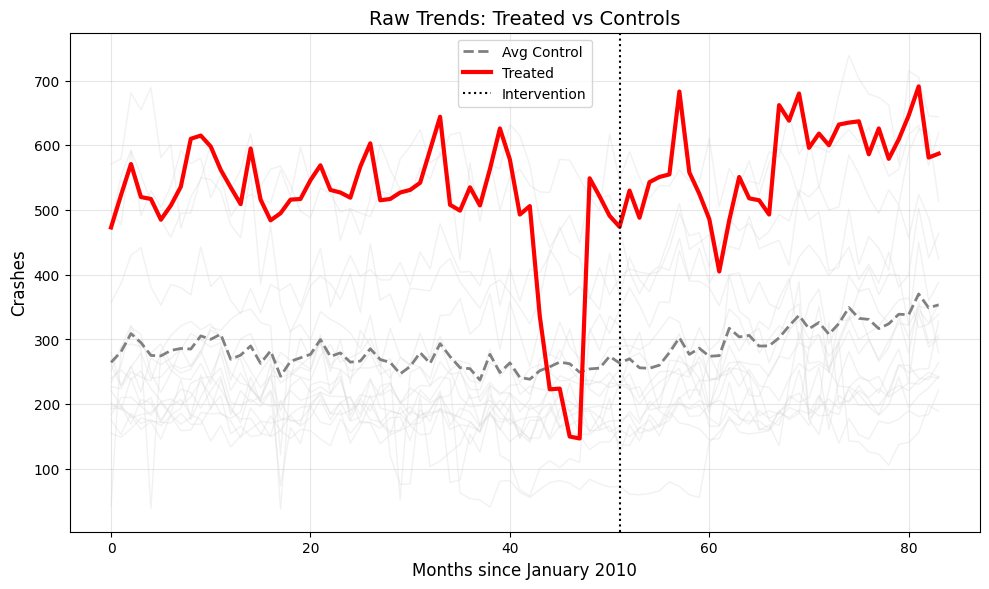

In [23]:
result = model.plot_raw_trends()

for ax in result.axes:
    ax.set_ylabel("Crashes")
    ax.set_xlabel("Months since January 2010")
    
print((result))

INFO:sdid.core:Creating synthetic control plot...


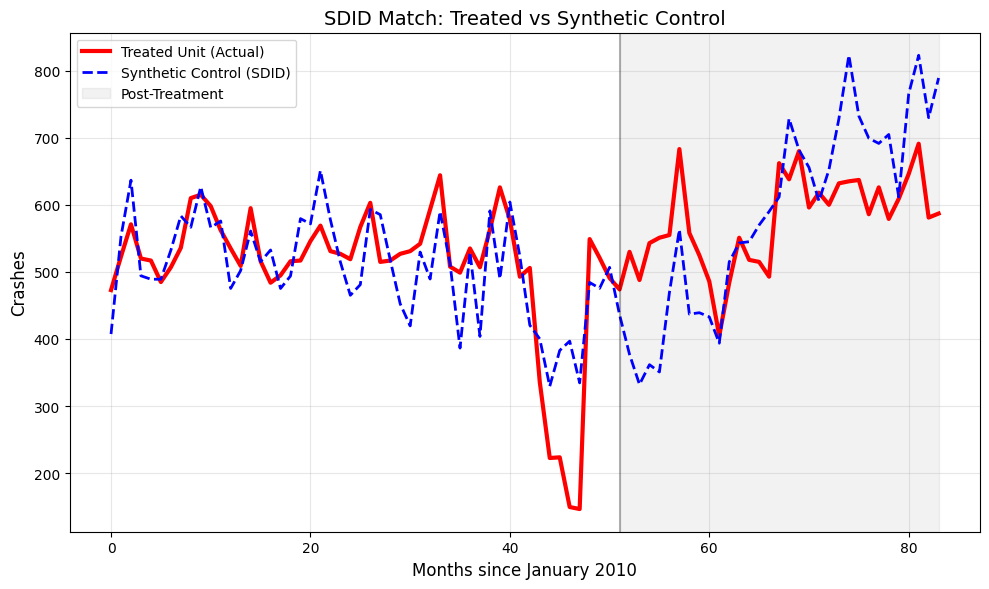

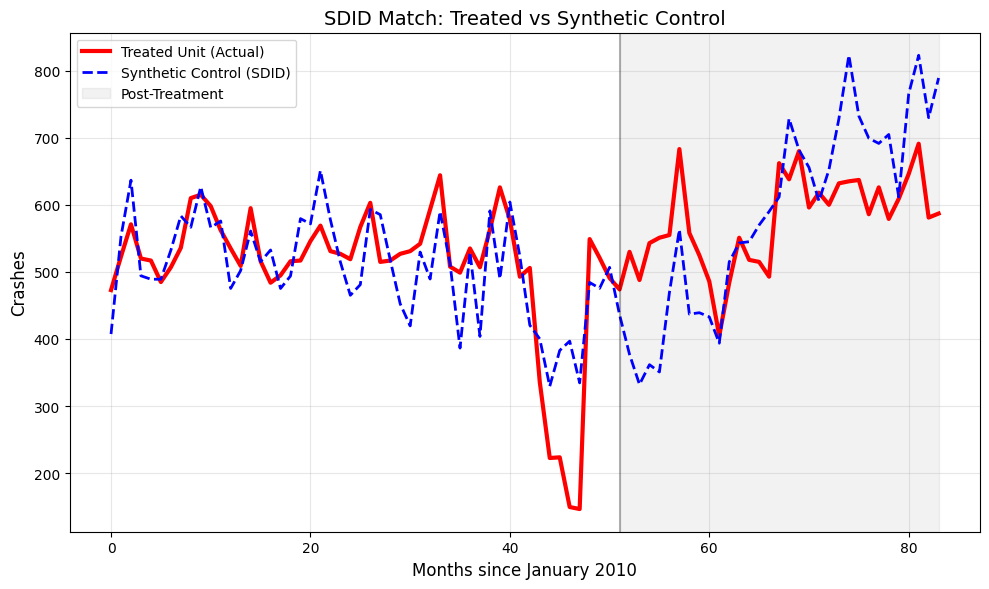

In [19]:
result2 = model.plot_synthetic_control()

for ax in result2.axes:
    ax.set_ylabel("Crashes")
    ax.set_xlabel("Months since January 2010")

result2

In [20]:
model.estimate_se(n_bootstrap=200, n_jobs=4)
print(model.summary(confidence_level = .95))

INFO:sdid.core:Estimating standard error with 200 bootstrap samples...
INFO:sdid.core:Standard error: 78.1205


Synthetic Difference-in-Differences Results
Treatment Effect (ATT): 171.7879
Standard Error:        78.1205
95% Confidence Interval: [18.6746, 324.9012]
t-statistic:           2.1990
p-value:               0.0279
Control units used:    6
Time periods used:     0


In [21]:
model.get_weights_summary()

{'unit_weights':                 weight  rank
 Agency                      
 Long Beach    1.130991   1.0
 Pasadena      0.841860   2.0
 Garden Grove  0.521374   3.0
 Riverside     0.508788   4.0
 Fresno        0.289043   5.0
 Stockton      0.074993   6.0,
 'time_weights': Empty DataFrame
 Columns: [weight, rank]
 Index: []}